In [ ]:
import pandas as pd
cbc = pd.read_csv("cbc_medexplain_synthetic_dataset.csv")
kb = pd.read_excel("Medical explanation knowledge base.xlsx")

print("CBC dataset shape:",cbc.shape)
print("Knowledge Base shape",kb.shape)

print("\n Columns:")
print(cbc.columns.tolist())

print("knowledge base:")
print(kb)
print("Null values in dataset:")
print(cbc.isnull().sum())

print("Null values in knowledge base:")
print(kb.isnull().sum())

CBC dataset shape: (100, 48)
Knowledge Base shape (9, 5)

 Columns:
['report_id', 'raw_report_text', 'overall_status', 'HGB_value', 'HGB_unit', 'HGB_ref_low', 'HGB_ref_high', 'HGB_status', 'HCT_value', 'HCT_unit', 'HCT_ref_low', 'HCT_ref_high', 'HCT_status', 'PLT_value', 'PLT_unit', 'PLT_ref_low', 'PLT_ref_high', 'PLT_status', 'MCV_value', 'MCV_unit', 'MCV_ref_low', 'MCV_ref_high', 'MCV_status', 'MCHC_value', 'MCHC_unit', 'MCHC_ref_low', 'MCHC_ref_high', 'MCHC_status', 'MCH_value', 'MCH_unit', 'MCH_ref_low', 'MCH_ref_high', 'MCH_status', 'RDW_value', 'RDW_unit', 'RDW_ref_low', 'RDW_ref_high', 'RDW_status', 'NE%_value', 'NE%_unit', 'NE%_ref_low', 'NE%_ref_high', 'NE%_status', 'LY%_value', 'LY%_unit', 'LY%_ref_low', 'LY%_ref_high', 'LY%_status']
knowledge base:
  parameter                                    meaning  \
0     HGB:                            Hemoglobin level   
1       HCT                           Hematocrit level   
2     PLT:                              Platelet count  

In [ ]:
print(cbc["overall_status"].value_counts())
print("Percentage distribution:")
print(cbc["overall_status"].value_counts(normalize=True)* 100)

overall_status
Abnormal    64
Normal      36
Name: count, dtype: int64
Percentage distribution:
overall_status
Abnormal    64.0
Normal      36.0
Name: proportion, dtype: float64


In [ ]:
status_columns =[
    "HGB_status",
    "HCT_status",
    "PLT_status",
    "MCV_status",
    "MCH_status",
    "MCHC_status",
    "RDW_status",
    "NE%_status",
    "LY%_status"
]

for col in status_columns:
  print("\n", col)
  print(cbc[col].value_counts())


 HGB_status
HGB_status
Normal    68
Low       22
High      10
Name: count, dtype: int64

 HCT_status
HCT_status
Normal    61
Low       26
High      13
Name: count, dtype: int64

 PLT_status
PLT_status
Normal    89
Low        7
High       4
Name: count, dtype: int64

 MCV_status
MCV_status
Normal    86
Low       14
Name: count, dtype: int64

 MCH_status
MCH_status
Normal    78
Low       21
High       1
Name: count, dtype: int64

 MCHC_status
MCHC_status
Normal    99
Low        1
Name: count, dtype: int64

 RDW_status
RDW_status
Normal    78
High      22
Name: count, dtype: int64

 NE%_status
NE%_status
Normal    86
High      14
Name: count, dtype: int64

 LY%_status
LY%_status
Normal    87
Low       13
Name: count, dtype: int64


In [ ]:
for i in range(5):
  print("="*70)
  print(cbc.loc[i,"raw_report_text"])

COMPLETE BLOOD COUNT

Hemoglobin: 14.2 g/dL  Reference: 12-16 g/dL
Hematocrit: 41 %  Reference: 36-46 %
Platelet Count: 244,000 /µL  Reference: 150000-450000 /µL
MCV: 95.5 fL  Reference: 80-100 fL
Mean Corpuscular Hemoglobin Concentration: 33.2 g/dL  Reference: 32-36 g/dL
MCH: 30.8 pg  Reference: 27-33 pg
RDW: 12.3 %  Reference: 11.5-14.5 %
Neutrophils: 83.6 %  Reference: 40-70 %
Lymphocytes: 14.1 %  Reference: 20-40 %
COMPLETE BLOOD COUNT

Hb: 11.9 g/dL  Reference: 12-16 g/dL
PCV: 35.5 %  Reference: 36-46 %
Platelets: 278,000 /µL  Reference: 150000-450000 /µL
Mean Corpuscular Volume: 86 fL  Reference: 80-100 fL
MCHC: 32.3 g/dL  Reference: 32-36 g/dL
Mean Corpuscular Hemoglobin: 29.6 pg  Reference: 27-33 pg
Red Cell Distribution Width: 12.6 %  Reference: 11.5-14.5 %
Neutrophil %: 59.4 %  Reference: 40-70 %
Lymphocyte %: 31.1 %  Reference: 20-40 %
COMPLETE BLOOD COUNT

HGB: 11 g/dL  Reference: 12-16 g/dL
HCT: 30.1 %  Reference: 36-46 %
PLT: 209,000 /µL  Reference: 150000-450000 /µL
MCV:

In [ ]:
def calculate_status(row,parameter):
  values=row[f"{parameter}_value"]
  low = row[f"{parameter}_ref_low"]
  high = row[f"{parameter}_ref_high"]

  if values < low:
    return "Low"
  elif values > high:
    return "High"
  else:
      return "Normal"

In [ ]:
for parameter in ['HGB', 'HCT', 'PLT', 'MCV', 'MCH', 'MCHC', 'RDW', 'NE%', 'LY%']:

  calculated = cbc.apply(
      lambda row: calculate_status(row, parameter),
      axis =1
    )

  actual = cbc[f"{parameter}_status"]

  print(
      parameter,
      "matches:",
      (calculated == actual).sum(),
      "/",
      len(cbc)
  )

HGB matches: 100 / 100
HCT matches: 100 / 100
PLT matches: 100 / 100
MCV matches: 100 / 100
MCH matches: 100 / 100
MCHC matches: 100 / 100
RDW matches: 100 / 100
NE% matches: 100 / 100
LY% matches: 100 / 100


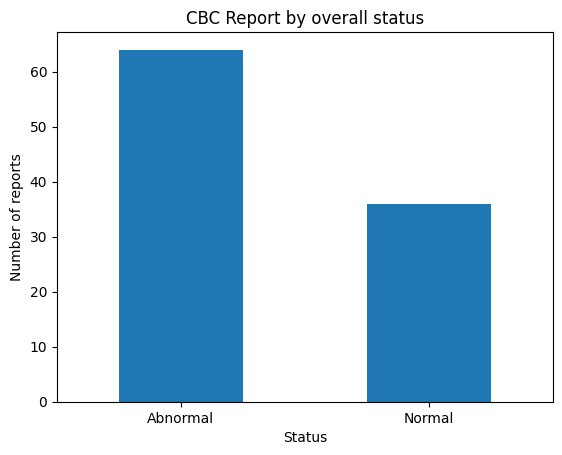

In [ ]:
# visualizer !: overall status

import matplotlib.pyplot as plt


cbc["overall_status"].value_counts().plot(kind="bar")

plt.title("CBC Report by overall status")
plt.xlabel('Status')
plt.ylabel("Number of reports")
plt.xticks(rotation = 0)
plt.show()

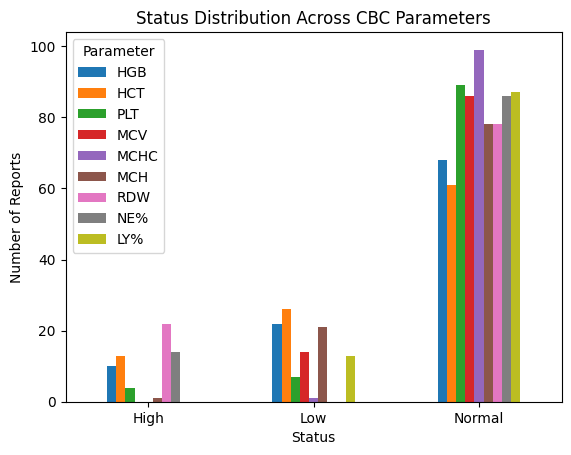

In [ ]:
# Visualizer 2: Parameter status distribution

status_counts = pd.DataFrame({
    "HGB": cbc["HGB_status"].value_counts(),
    "HCT": cbc["HCT_status"].value_counts(),
    "PLT": cbc["PLT_status"].value_counts(),
    "MCV": cbc["MCV_status"].value_counts(),
    "MCHC": cbc["MCHC_status"].value_counts(),
    "MCH": cbc["MCH_status"].value_counts(),
    "RDW": cbc["RDW_status"].value_counts(),
    "NE%": cbc["NE%_status"].value_counts(),
    "LY%": cbc["LY%_status"].value_counts()
})

status_counts.plot(kind="bar")

plt.title("Status Distribution Across CBC Parameters")
plt.xlabel("Status")
plt.ylabel("Number of Reports")
plt.xticks(rotation=0)
plt.legend(title="Parameter")
plt.show()

In [ ]:
clean_df = cbc.copy()

# Remove accidental spaces from column names
clean_df.columns = clean_df.columns.str.strip()

# Clean report text
clean_df["raw_report_text"] = (
    clean_df["raw_report_text"]
    .astype(str)
    .str.strip()
)

# Clean overall status
clean_df["overall_status"] = (
    clean_df["overall_status"]
    .astype(str)
    .str.strip()
)

print(clean_df.head())

  report_id                                    raw_report_text overall_status  \
0   CBC_001  COMPLETE BLOOD COUNT\n\nHemoglobin: 14.2 g/dL ...       Abnormal   
1   CBC_002  COMPLETE BLOOD COUNT\n\nHb: 11.9 g/dL  Referen...       Abnormal   
2   CBC_003  COMPLETE BLOOD COUNT\n\nHGB: 11 g/dL  Referenc...       Abnormal   
3   CBC_004  COMPLETE BLOOD COUNT\n\nHemoglobin: 14.5 g/dL ...       Abnormal   
4   CBC_005  COMPLETE BLOOD COUNT\n\nHb: 14.1 g/dL  Referen...         Normal   

   HGB_value HGB_unit  HGB_ref_low  HGB_ref_high HGB_status  HCT_value  \
0       14.2     g/dL         12.0          16.0     Normal       41.0   
1       11.9     g/dL         12.0          16.0        Low       35.5   
2       11.0     g/dL         12.0          16.0        Low       30.1   
3       14.5     g/dL         12.0          16.0     Normal       42.5   
4       14.1     g/dL         12.0          16.0     Normal       40.7   

  HCT_unit  ...  NE%_value  NE%_unit NE%_ref_low  NE%_ref_high NE%_s

In [ ]:
clean_df.to_csv(
    "cbc_medexplain_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
